# Functional Density Forecasting (FDF)

## Monte Carlo Simulation

### Design

To conduct the Monte Carlo simulation study, the modified log-quantile density transformation is employed within a functional data framework.

Let $\{Y_t\}_{t=1}^T$ denote a sequence of random elements in $L^2(\mathcal{U})$, defined as
\begin{equation}
Y_t(u) = \Lambda_q(f)(u) + X_t(u) + \varepsilon_t(u), \quad u \in \mathcal{U},
\end{equation}
where $\Lambda_q(f)$ is the transformed baseline density function, $X_t(u)$ is a latent stochastic process capturing temporal dependence, and $\varepsilon_t(u)$ is a noise component.

The baseline density function $f$ is specified to reflect stylized features of financial return distributions, such as heavy tails and asymmetry, and is mapped into the Hilbert space $L^2(\mathcal{U})$ via the modified log-quantile density transformation $\Lambda_q$. In this setting, $\Lambda_q(f)$ acts as a deterministic reference function in the transformed space.

Temporal dependence is introduced through a finite Fourier-type expansion,
\begin{equation}
X_t(u) = \sum_{j=1}^p W_{jt} \phi_j(u),
\end{equation}
where $\phi_j(u) = \sin(2\pi j u)$ are basis functions, and the coefficients $\{W_{jt}\}$ follow independent AR(1) processes,
\begin{equation}
W_{jt} = \rho_j W_{j,t-1} + \eta_{jt}, \quad \eta_{jt} \sim \mathcal{N}(0, \sigma_j^2).
\end{equation}

The noise component is modeled as a Brownian bridge process,
\begin{equation}
\varepsilon_t(u) \sim \mathcal{BB}(0, \sigma_\varepsilon^2),
\end{equation}
ensuring smooth perturbations that preserve boundary conditions.

Finally, the simulated functional observations are mapped back to the density space via the inverse transformation,
\begin{equation}
f_t = \Lambda_q^{-1}\big(Y_t\big) 
= \Lambda_q^{-1} \left\{ \Lambda_q(f)(u) + \sum_{j=1}^p W_{jt} \phi_j(u) + \varepsilon_t(u) \right\}.
\end{equation}

This construction yields a sequence of density functions $\{f_t\}_{t=1}^T$ that exhibit realistic distributional features and controlled temporal dependence, providing a suitable framework for evaluating density forecasting methods.

### Code

In [68]:
import numpy as np
import scipy

import sys 
sys.path.append('../../')
import src.legacy.simulations as sim
import src.fda.transformations.lqdt as lqdt

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (15, 5)

In [ ]:
def simulate_dependent_densities(n_days, lqd_template, phis, sigma=0.1):
    """
    Simulates a sequence of LQD curves with temporal dependence.
    
    Args:
        n_days (int): Number of days to simulate.
        lqd_template (array): Your smooth T-distribution LQD (shape: nt,).
        phis (list): AR(1) coefficients for each 'flavor' of movement.
        sigma (float): Volatility of the daily changes.
    """
    nt = len(lqd_template)
    K = len(phis)
    u = np.linspace(0, 1, nt)
    
    # 1. Initialize the 'Scores' (How much of each cosine we use each day)
    # Shape: (K, n_days)
    scores = np.zeros((K, n_days))
    for k in range(K):
        # Daily shocks (Innovation)
        shocks = np.random.normal(scale=sigma, size=n_days)
        for t in range(1, n_days):
            scores[k, t] = phis[k] * scores[k, t-1] + shocks[t]
            
    # 2. Define the 'Shapes' (The basis functions)
    # We use sqrt(2)*cos to keep things orthonormal in L2
    basis = np.array([np.sqrt(2) * np.cos(np.pi * (k+1) * u) for k in range(K)])
    
    # 3. Combine: Template + (Scores * Basis)
    # We use matrix multiplication (@) for the 'perturbation' part
    perturbations = (scores.T @ basis).T # Result shape: (nt, n_days)
    
    # Add the template to every single day
    simulated_lqds = lqd_template[:, None] + perturbations
    
    return simulated_lqds, scores

def simulate_hilbert_process(
    n: int,           # number of curves
    nt: int,          # grid size
    u: np.ndarray,    # nt x 1 grid over [0,1]
    base_f,           # Base function (already in L2)
    phis,             # AR parameters for the scores W_kt
    variance=0.01     # Variance for the innovations
    ):
    """
    Simulates functional data curves Y_t(u) in a Hilbert space context, 
    incorporating serial dependence and Brownian Bridge noise.

    The simulation follows the additive model:
    Y_t(u) = [Λ_q(f)(u) + X_0t(u)] + ε_t(u)

    Mathematical Components:
    ------------------------
    1. Base Signal [Λ_q(f)(u)]: 
       The 'center' of the distribution in the Hilbert space. This is provided 
       via the `base_f` argument, representing a density (e.g., Gaussian or 
       Student-t) already mapped into L2 via a transformation (like the CLR 
       or isometric log-ratio transform).

    2. Serial Dependence [X_0t(u)]:
       Modeled as a finite sum of harmonics: 
       X_0t(u) = Σ_{k=1}^K W_{kt} * sin(2 * k * π * u)
       where the scores W_{kt} follow an AR(1) process:
       W_{kt} = φ_k * W_{k,t-1} + η_{kt},  η_{kt} ~ N(0, σ^2)
       This captures how the shape of the curves evolves over time 't'.

    3. Functional Noise [ε_t(u)]:
       Represented by a Brownian Bridge (BB_t). Unlike standard white noise, 
       the Brownian Bridge ensures:
       - ε_t(0) = ε_t(1) = 0 (Boundary constraints)
       - Cov(ε(s), ε(t)) = min(s,t) - s*t
       This provides a realistic, continuous but non-differentiable 
       stochastic perturbation to the functional observations.

    Parameters:
    -----------
    n : int
        Number of curves to simulate (temporal dimension).
    nt : int
        Number of grid points (spatial/domain dimension u).
    u : np.ndarray
        A (nt x 1) or (nt,) array representing the grid over the domain [0, 1].
    base_f : np.ndarray
        A (nt x 1) or (nt,) array representing the transformed base density 
        function Λ_q(f).
    phis : list or np.ndarray
        List of K autoregressive parameters. Each φ_k corresponds to the 
        dependence of the k-th harmonic score.
    variance : float, optional
        The variance (σ^2) of the innovations for the AR(1) scores. 
        Default is 0.01.

    Returns:
    --------
    Y : np.ndarray (nt x n)
        The observed functional data (Signal + Noise).
    X0 : np.ndarray (nt x n)
        The latent serial dependence component.
    BB : np.ndarray (nt x n)
        The realized Brownian Bridge noise for each curve.
    """
    K = len(phis)
    u = u.flatten()
    
    # 1. Simulate Latent Scores (W_kt) using AR(1) processes
    # These drive the serial dependence X_0t
    W = np.zeros((K, n))
    for k in range(K):
        # Innovation noise
        eps = np.random.normal(scale=np.sqrt(variance), size=n)
        for t in range(1, n):
            W[k, t] = phis[k] * W[k, t - 1] + eps[t]

    # 2. Build Serial Dependence Structure: X_0t(u)
    # Using the sine basis as specified: sum W_kt * sin(2*k*pi*u)
    X0 = np.zeros((nt, n))
    for k in range(K):
        # Note: k+1 used to avoid sin(0)
        X0 += W[k][None, :] * np.sin(2 * (k + 1) * np.pi * u[:, None])

    # 3. Generate Brownian Bridge Noise: BB_t(u)
    # This acts as the epsilon_t(u) term
    BB = np.zeros((nt, n))
    dt = 1.0 / (nt - 1)
    for t in range(n):
        dw = np.random.normal(scale=np.sqrt(dt), size=nt)
        dw[0] = 0
        w = np.cumsum(dw)
        # Brownian Bridge formula: B(u) = W(u) - u*W(1)
        BB[:, t] = w - u * w[-1]

    # 4. Assemble Y_t(u)
    # base_f is expected to be (nt, 1) or (nt,)
    if base_f.ndim == 1:
        base_f = base_f[:, None]
        
    Y = base_f + X0 + BB

    return Y, X0, BB

#### New code

In [ ]:
# New code

def generate_base_density(grid, kind="gaussian", params=None):
    """
    Returns a density f(x) evaluated on a grid.
    """
    if kind == "gaussian":
        mu = params.get("mu", 0)
        sigma = params.get("sigma", 1)
        f = scipy.stats.norm.pdf(grid, mu, sigma)
        
    elif kind == "student_t":
        df = params.get("df", 5)
        f = scipy.stats.t.pdf(grid, df)
        
    elif kind == "mixture":
        w = params.get("weights", [0.5, 0.5])
        mus = params.get("means", [-2, 2])
        sigmas = params.get("sigmas", [1, 1])
        
        f = sum(
            w[i] * scipy.stats.norm.pdf(grid, mus[i], sigmas[i])
            for i in range(len(w))
        )
    
    return f / np.trapz(f, grid)  # normalize

In [3]:
def transform_to_l2(f, grid):
    """
    Apply modified Log Quantile Density Transform (mLQDT).
    """
    # Pseudo-steps (adapt to your implementation)
    F = np.cumsum(f) / np.sum(f)
    Q = np.interp(grid, F, grid)  # quantile function
    
    lqd = np.log(np.gradient(Q, grid))
    
    return lqd

In [4]:
def simulate_ar_scores(n, phis, sigma):
    """
    Simulates AR(1) score processes W_{kt}.
    
    Returns:
        scores: (K, n)
    """
    K = len(phis)
    scores = np.zeros((K, n))
    
    for k in range(K):
        shocks = np.random.normal(scale=sigma, size=n)
        for t in range(1, n):
            scores[k, t] = phis[k] * scores[k, t-1] + shocks[t]
    
    return scores

In [5]:
def build_cosine_basis(K, u):
    """
    կառուցces an orthonormal cosine basis in L2[0,1].
    
    Returns:
        basis: (K, nt)
    """
    return np.array([
        np.sqrt(2) * np.cos(np.pi * (k + 1) * u)
        for k in range(K)
    ])

In [6]:
def build_dependence(scores, basis):
    """
    Computes X_t(u) = sum_k W_{kt} * phi_k(u)
    
    Returns:
        X: (nt, n)
    """
    return (scores.T @ basis).T

In [81]:
def simulate_brownian_bridge(n, nt, u, sigma_bb=0.05):
    """
    Simulates Brownian bridge noise ε_t(u).
    
    Returns:
        BB: (nt, n)
    """
    BB = np.zeros((nt, n))
    dt = 1 / (nt - 1)

    for t in range(n):
        dw = np.random.normal(scale=np.sqrt(dt), size=nt)
        w = np.cumsum(dw)
        bb = w - u * w[-1]
        BB[:, t] = sigma_bb * bb   # ← key change

    return BB

def simulate_white_noise(n, nt, sigma):
    """
    Simple iid functional noise.
    """
    return np.random.normal(scale=sigma, size=(nt, n))

In [9]:
def assemble_l2_process(base_lqd, X, noise):
    """
    Combines all components:
    
    Y_t(u) = base_lqd + X_t(u) + ε_t(u)
    """
    if base_lqd.ndim == 1:
        base_lqd = base_lqd[:, None]
        
    return base_lqd + X + noise

In [70]:
import pandas as pd

def simulate_l2_process(
    n,
    base_lqd,
    u,
    phis,
    sigma=0.1,
    noise_type="bridge",
    as_dataframe=False,
    date_init=None,
    date_end=None
):
    """
    Simulate a functional time series in L2 via basis-driven dynamics.

    Generates curves Y_t(u) = base_lqd(u) + X_t(u) + ε_t(u), where X_t(u)
    is constructed from AR(1) score processes and an orthonormal cosine basis,
    and ε_t(u) is either Brownian bridge or white noise.

    Parameters
    ----------
    n : int
        Number of curves (time points).
    base_lqd : array-like, shape (nt,)
        Mean function in L2 space.
    u : array-like, shape (nt,)
        Grid over [0, 1].
    phis : array-like, shape (K,)
        AR(1) coefficients.
    sigma : float, optional
        Innovation standard deviation.
    noise_type : {"bridge", "white"}, optional
        Type of functional noise.
    as_dataframe : bool, optional
        If True, return Y as a pandas DataFrame with a daily date index.
    date_init : str or datetime-like, optional
        Start date for the index.
    date_end : str or datetime-like, optional
        End date for the index.

    Returns
    -------
    Y : ndarray or DataFrame, shape (nt, n)
        Simulated functional data.
    scores : ndarray, shape (K, n)
    X : ndarray, shape (nt, n)
    noise : ndarray, shape (nt, n)

    Notes
    -----
    If `as_dataframe=True` and no dates are provided, columns are set to the
    last `n` calendar days ending today.

    Example
    -------
    >>> Y, *_ = simulate_l2_process(
    ...     n=30,
    ...     base_lqd=base_lqd,
    ...     u=u,
    ...     phis=[0.8, 0.5],
    ...     as_dataframe=True
    ... )
    """

    nt = len(u)
    K = len(phis)

    scores = simulate_ar_scores(n, phis, sigma)
    basis = build_cosine_basis(K, u)
    X = build_dependence(scores, basis)

    if noise_type == "bridge":
        noise = simulate_brownian_bridge(n, nt, u)
    else:
        noise = simulate_white_noise(n, nt, sigma)

    Y = assemble_l2_process(base_lqd, X, noise)

    if as_dataframe:
        # --- Date logic ---
        if date_init is None and date_end is None:
            dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=n, freq="D")
        elif date_end is not None and date_init is None:
            dates = pd.date_range(end=date_end, periods=n, freq="D")
        elif date_init is not None and date_end is None:
            dates = pd.date_range(start=date_init, periods=n, freq="D")
        else:
            dates = pd.date_range(start=date_init, end=date_end, freq="D")
            if len(dates) != n:
                raise ValueError("date range length must match n")

        Y = pd.DataFrame(Y, index=u, columns=dates)

    return Y, scores, X, noise

In [82]:
import numpy as np
u = np.linspace(0, 1, 100)
base_lqd = np.sin(2 * np.pi * u)  # example mean function in L2
phis = [0.8, 0.5]
Y, scores, X, noise = simulate_l2_process(
    n=50,
    base_lqd=base_lqd,
    u=u,
    phis=phis,
    sigma=0.1,
    noise_type="bridge",
    as_dataframe=True
)

<Axes: title={'center': 'simulated_curves'}>

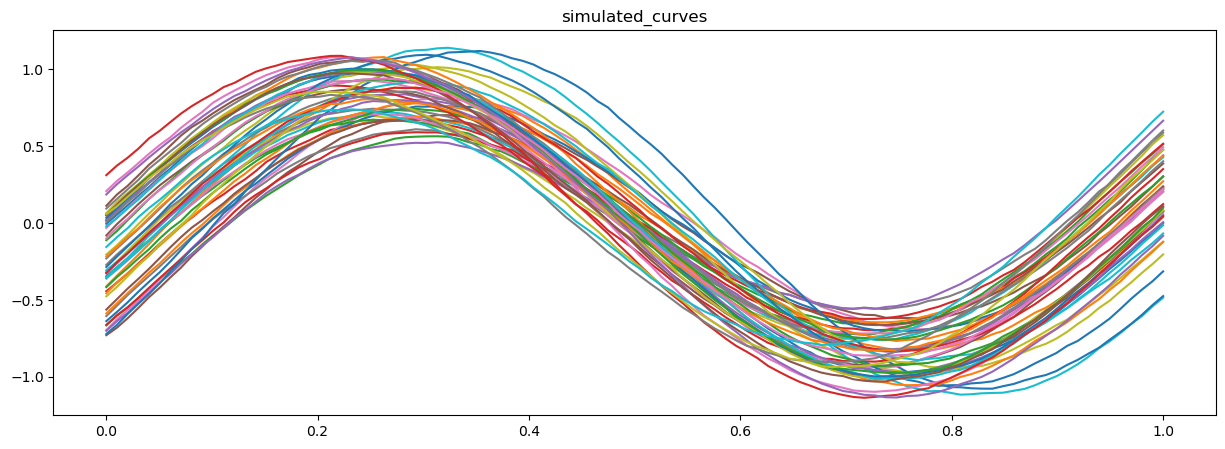

In [83]:
Y.plot(title="simulated_curves", legend=False)

In [84]:
m = 1000
x = np.linspace(-6, 6, m)
u = np.linspace(0, 1, m)

pdf_t3     = sim.t_density(x, df=3)
pdf_t5     = sim.t_density(x, df=5)
pdf_normal = sim.normal_density(x)

lqd_support = np.linspace(0,1,m)
t0_ = x[np.argmin(np.abs(x))]
lqdsup, lqd_t, c = lqdt.dens2lqd(
                        dens = pdf_t3, 
                        dSup = x, 
                        lqdSup=lqd_support, 
                        t0 = t0_,
                        verbose=True
                        )
lqdsup, lqd_n, c = lqdt.dens2lqd(
                        dens = pdf_normal, 
                        dSup = x, 
                        lqdSup=lqd_support, 
                        t0 = t0_,
                        verbose=True
)

<Axes: >

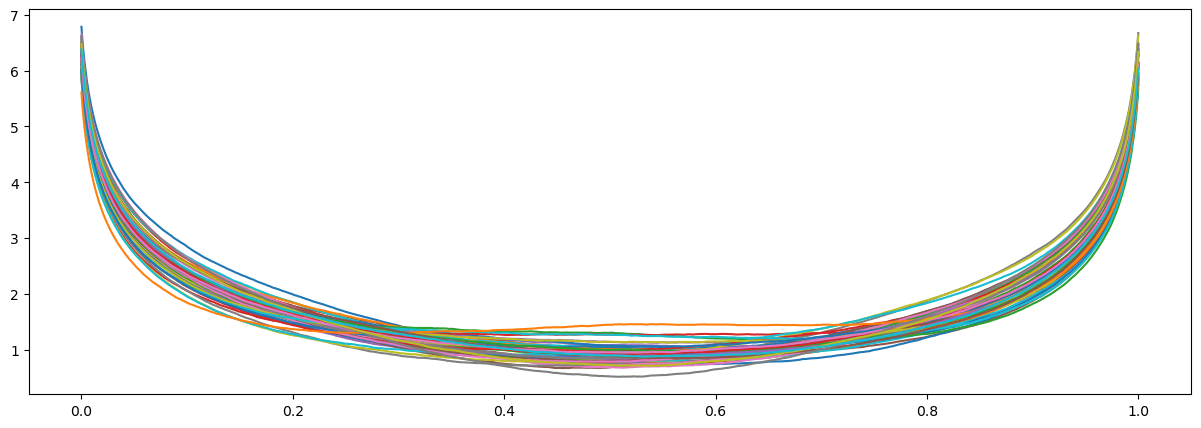

In [85]:
phis = [0.8, 0.5]
Y, scores, X, noise = simulate_l2_process(
    n=50,
    base_lqd=lqd_t,
    u=u,
    phis=phis,
    sigma=0.1,
    noise_type="bridge",
    as_dataframe=True
)

Y.plot(legend=False)

<Axes: >

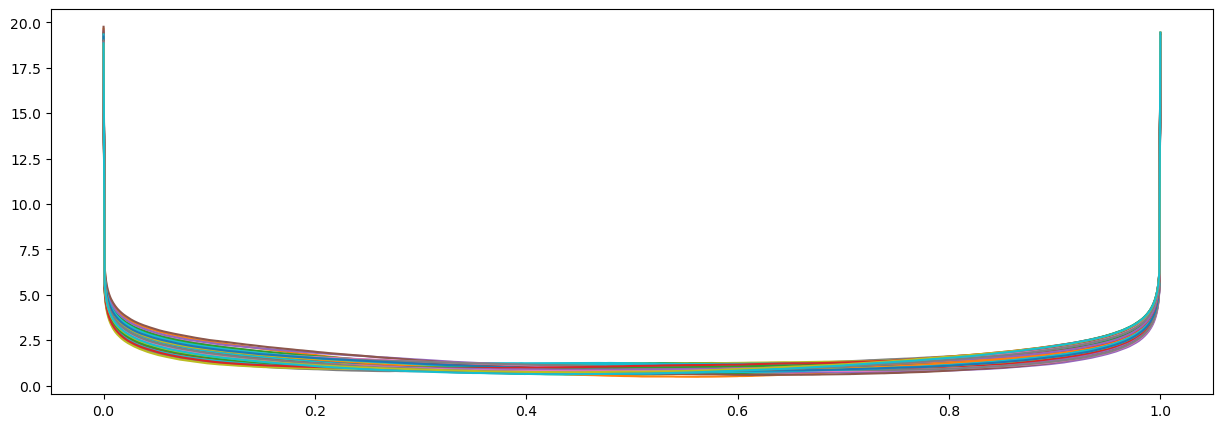

In [86]:
phis = [0.8, 0.5]
Y, scores, X, noise = simulate_l2_process(
    n=50,
    base_lqd=lqd_n,
    u=u,
    phis=phis,
    sigma=0.1,
    noise_type="bridge",
    as_dataframe=True
)

Y.plot(legend=False)